# Домашнее задание к семинару 06 (HW06)

Тема: деревья решений и ансамбли (bagging / random forest / boosting / stacking) и честный ML-эксперимент.

## 2. Задание

### 2.1. Структура для HW06 (обязательно)

1) В корне репозитория должна быть папка `homeworks/` (создать, если её ещё нет).  
2) Внутри `homeworks/` создать папку `HW06/`.  
3) В папке `homeworks/HW06/` создать:

- основной ноутбук: `HW06.ipynb`
- отчёт: `report.md`
- папку для артефактов: `artifacts/`
  - рекомендуется внутри `artifacts/` завести подпапку `figures/` для графиков

### 2.2. Учебные датасеты S06 (выбрать один из четырёх)

Выбран - `S06-hw-dataset-02.csv` – бинарная классификация, более "сложная": больше шума/перекрытия классов, плюс добавлены несколько явно нелинейных взаимодействий признаков.  
  Обычно это хороший вариант, чтобы увидеть, как ансамбли выигрывают у базовых моделей.

#### 2.3.1. Загрузка данных и первичный анализ

1) Импортировать библиотеки: `pandas`, `numpy`, `scikit-learn` (модели, CV, метрики), `matplotlib` (для графиков).  
2) Загрузить выбранный CSV в `pandas.DataFrame`.  
3) Зафиксировать минимум:

   - `head()`, `info()`, базовые статистики (`describe()` или аналог);
   - распределение таргета `target` (доли классов);
   - (желательно) проверку пропусков и типы столбцов.

In [99]:
import os, json
from pathlib import Path

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, StratifiedKFold, GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier, GradientBoostingClassifier, HistGradientBoostingClassifier
from sklearn.metrics import (
    accuracy_score, f1_score, roc_auc_score,
    confusion_matrix, ConfusionMatrixDisplay,
    RocCurveDisplay, PrecisionRecallDisplay,
)
from sklearn.inspection import permutation_importance

import joblib

In [100]:
df = pd.read_csv("S06-hw-dataset-02.csv")
df.head()

,id,f01,f02,f03,f04,f05,f06,f07,f08,f09,...,f29,f30,f31,f32,f33,f34,f35,x_int_1,x_int_2,target
0,1,-0.149235,-2.826966,-0.522901,-4.198449,1.364943,0.815043,-1.195518,-1.932232,2.396353,...,-0.159323,0.448015,0.572745,0.149916,0.878392,-0.679733,1.412751,0.421883,9.217167,1
1,2,-1.966180,-4.877542,0.268367,-9.607791,0.097149,1.347185,-3.872575,-0.395117,1.710068,...,-0.389212,1.383794,0.169876,0.043969,-0.963545,1.006643,-2.488690,9.590124,24.772826,0
2,3,-0.555964,-0.999920,0.209673,-14.119498,-1.808950,-0.006222,-4.651108,0.911944,-0.289037,...,-1.383970,3.044321,-0.182864,1.425649,-8.418598,-4.629754,-0.439798,0.555919,41.800517,0
3,4,-2.049199,-5.600713,-1.664677,-6.263893,-5.224455,0.848351,1.407210,-0.542080,0.119102,...,-2.713080,2.762637,-0.520796,-0.142455,1.668338,2.292810,-10.744916,11.476977,65.315860,0
4,5,-0.220556,4.889479,-2.235840,6.450046,0.774389,-2.382625,2.584816,4.211856,-0.317889,...,-1.302872,2.478862,1.528610,1.098131,3.547087,2.517757,-9.364106,-1.078404,93.017870,0


In [101]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 18000 entries, 0 to 17999
Data columns (total 39 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   id       18000 non-null  int64  
 1   f01      18000 non-null  float64
 2   f02      18000 non-null  float64
 3   f03      18000 non-null  float64
 4   f04      18000 non-null  float64
 5   f05      18000 non-null  float64
 6   f06      18000 non-null  float64
 7   f07      18000 non-null  float64
 8   f08      18000 non-null  float64
 9   f09      18000 non-null  float64
 10  f10      18000 non-null  float64
 11  f11      18000 non-null  float64
 12  f12      18000 non-null  float64
 13  f13      18000 non-null  float64
 14  f14      18000 non-null  float64
 15  f15      18000 non-null  float64
 16  f16      18000 non-null  float64
 17  f17      18000 non-null  float64
 18  f18      18000 non-null  float64
 19  f19      18000 non-null  float64
 20  f20      18000 non-null  float64
 21  f21      180

In [102]:
df.describe(include="all")

,id,f01,f02,f03,f04,f05,f06,f07,f08,f09,...,f29,f30,f31,f32,f33,f34,f35,x_int_1,x_int_2,target
count,18000.000000,18000.000000,18000.000000,18000.000000,18000.000000,18000.000000,18000.000000,18000.000000,18000.000000,18000.000000,...,18000.000000,18000.000000,18000.000000,18000.000000,18000.000000,18000.000000,18000.000000,18000.000000,1.800000e+04,18000.000000
mean,9000.500000,-0.418555,0.614251,0.004559,0.059000,0.405086,0.012123,-0.283473,-0.266880,0.255107,...,-0.139825,0.108568,0.007238,0.000904,-0.716862,-0.274520,0.344991,1.517339,2.576221e+01,0.262611
std,5196.296758,2.178005,3.926778,1.000134,5.713672,2.497581,0.987226,2.193891,2.081431,2.225776,...,2.148834,2.234315,0.997861,1.002115,3.913704,2.482890,4.927315,10.630850,5.423748e+01,0.440065
min,1.000000,-10.014698,-15.510323,-4.031762,-23.663256,-12.289308,-3.741536,-9.591425,-8.293319,-13.655742,...,-8.171469,-9.214171,-3.937091,-3.963063,-19.389908,-10.031559,-20.768452,-107.788145,1.895059e-07,0.000000
25%,4500.750000,-1.866134,-2.048192,-0.673127,-3.544964,-1.153000,-0.653090,-1.743214,-1.688121,-1.177480,...,-1.589638,-1.369266,-0.663023,-0.684164,-3.286842,-1.897893,-2.752685,-2.018750,1.226029e+00,0.000000
50%,9000.500000,-0.465100,0.600291,0.003581,0.072826,0.485625,0.018765,-0.251263,-0.302463,0.350739,...,-0.204785,0.158715,0.001912,-0.003157,-0.618472,-0.339901,0.573153,0.318011,6.581865e+00,0.000000
75%,13500.250000,0.966393,3.229850,0.671390,3.689490,2.075739,0.689304,1.195481,1.109589,1.764113,...,1.254595,1.600671,0.677296,0.676558,1.948803,1.314163,3.649794,4.212111,2.576847e+01,1.000000
max,18000.000000,9.589975,15.417329,3.817025,26.815691,10.665184,3.528280,7.794627,8.892834,8.699629,...,9.290667,8.794320,4.341030,3.781380,14.065595,10.639974,20.226291,94.891804,1.103449e+03,1.000000


In [103]:
df.isna().sum().sort_values()

id         0
f21        0
f22        0
f23        0
f24        0
f25        0
f26        0
f27        0
f20        0
f28        0
f30        0
f31        0
f32        0
f33        0
f34        0
f35        0
x_int_1    0
f29        0
x_int_2    0
f19        0
f17        0
f01        0
f02        0
f03        0
f04        0
f05        0
f06        0
f07        0
f18        0
f08        0
f10        0
f11        0
f12        0
f13        0
f14        0
f15        0
f16        0
f09        0
target     0
dtype: int64

In [104]:
df["target"].value_counts()

target
0    13273
1     4727
Name: count, dtype: int64

4) Определить:

   - `X` – признаки (все столбцы, кроме `target`; столбец `id` не использовать как признак);
   - `y` – таргет (`target`).

In [105]:
X = df.drop(columns=["target", "id"])
y = df["target"]

#### 2.3.2. Train/Test-сплит и воспроизводимость

1) Разделить данные на train/test:

   - `test_size` разумный (например, 0.2 или 0.25);
   - обязательно фиксировать `random_state` (например, 42);
   - для классификации – использовать `stratify=y`.

In [106]:
RANDOM_STATE = 42

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=RANDOM_STATE,
    stratify=y, 
)

2) Коротко пояснить, почему фиксированный seed и стратификация важны.

random_state — чтобы при перезапуске был такой же split.
stratify=y — чтобы доли классов в train/test были похожи.

#### 2.3.3. Baseline’ы

Сделать минимум два baseline’а:

1) `DummyClassifier` (например, `most_frequent` или `stratified`).  
2) `LogisticRegression` (желательно через `Pipeline(StandardScaler + LogisticRegression)`).

Для обоих baseline’ов посчитать метрики на test (см. ниже) и кратко интерпретировать.

#### Baseline 1: DummyClassifier

In [107]:
dummy = DummyClassifier(strategy="most_frequent", random_state=RANDOM_STATE)
dummy.fit(X_train, y_train)

pred = dummy.predict(X_test)

acc_dummy = accuracy_score(y_test, pred)
f1_dummy = f1_score(y_test, pred)

print("Dummy accuracy:", acc)
print("Dummy f1:", f1)

Dummy accuracy: 0.8119444444444445
Dummy f1: 0.5606748864373783


#### Baseline 2: LogisticRegression (со StandardScaler)

In [108]:
logreg = Pipeline([
    ("scaler", StandardScaler()),
    ("clf", LogisticRegression(max_iter=2000, random_state=42))
])

logreg.fit(X_train, y_train)

pred = logreg.predict(X_test)
proba = logreg.predict_proba(X_test)[:, 1]

acc_logreg = accuracy_score(y_test, pred)
f1_logreg = f1_score(y_test, pred)
auc_logreg = roc_auc_score(y_test, proba)

print("LogReg accuracy:", acc)
print("LogReg f1:", f1)
print("LogReg ROC-AUC:", auc)

LogReg accuracy: 0.8119444444444445
LogReg f1: 0.5606748864373783
LogReg ROC-AUC: 0.7976914875596609


#### 2.3.4. Модели недели 6 (обязательно)

Реализовать и сравнить минимум 3 модели недели 6 (рекомендуется 4):

Подбор гиперпараметров:

- выполнять **только на train** через CV (`GridSearchCV` или аккуратный перебор);
- test использовать **один раз** для финальной оценки.

In [109]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

- `DecisionTreeClassifier`  
  Обязательно показать **контроль сложности** (например, `max_depth` + `min_samples_leaf`; или `ccp_alpha`).

In [110]:
tree = DecisionTreeClassifier(random_state=RANDOM_STATE)
params_tree = {
    "max_depth": [2, 3, 4, 5, 7, 10, 12, None],
    "min_samples_leaf": [1, 2, 5, 10, 18,  20, 25,  40]
}


search_tree = GridSearchCV(
    tree,
    param_grid=params_tree,
    scoring="roc_auc",
    cv=cv,
    n_jobs=-1
)


search_tree.fit(X_train, y_train)

print("Tree best params:", search_tree.best_params_)
print("Tree best CV score:", search_tree.best_score_)

Tree best params: {'max_depth': 10, 'min_samples_leaf': 20}
Tree best CV score: 0.8371670685048336


In [111]:
best_tree = search_tree.best_estimator_

pred_tree = best_tree.predict(X_test)
proba_tree = best_tree.predict_proba(X_test)[:, 1]

acc_tree = accuracy_score(y_test, pred_tree)
f1_tree = f1_score(y_test, pred_tree)
auc_tree = roc_auc_score(y_test, proba_tree)

print("Tree accuracy:", acc_tree)
print("Tree f1:", f1_tree)
print("Tree ROC-AUC:", auc_tree)


Tree accuracy: 0.8336111111111111
Tree f1: 0.6515415939499709
Tree ROC-AUC: 0.8372935162765671


- `RandomForestClassifier`  
  Желательно посмотреть хотя бы одну из "лесных" ручек (`max_features`, `min_samples_leaf`, `max_depth`).

In [112]:
rf = RandomForestClassifier(
    n_estimators=50,      
    random_state=RANDOM_STATE,
    n_jobs=-1
)

params_rf = {
    "max_depth": [None, 5, 10, 15],
    "min_samples_leaf": [1, 2, 5, 10],
    "max_features": ["sqrt", 0.5, None]
}

search_rf = GridSearchCV(
    rf,
    param_grid=params_rf,
    scoring="roc_auc",
    cv=cv,
    n_jobs=-1
)

search_rf.fit(X_train, y_train)

print("RF best params:", search_rf.best_params_)
print("RF best CV score:", search_rf.best_score_)


RF best params: {'max_depth': None, 'max_features': 'sqrt', 'min_samples_leaf': 5}
RF best CV score: 0.9235500919672106


In [113]:
best_rf = search_rf.best_estimator_

pred_rf = best_rf.predict(X_test)
proba_rf = best_rf.predict_proba(X_test)[:, 1]

acc_rf = accuracy_score(y_test, pred_rf)
f1_rf = f1_score(y_test, pred_rf)
auc_rf = roc_auc_score(y_test, proba_rf)

print("RF accuracy:", acc_rf)
print("RF f1:", f1_rf)
print("RF ROC-AUC:", auc_rf)


RF accuracy: 0.8858333333333334
RF f1: 0.745195288282703
RF ROC-AUC: 0.9203037096822408


- Один boosting на выбор:
  - `AdaBoostClassifier` или
  - `GradientBoostingClassifier` или
  - `HistGradientBoostingClassifier`

In [114]:
gb = GradientBoostingClassifier(random_state=RANDOM_STATE)

params_gb = {
    "n_estimators": [100, 200, 400],
    "learning_rate": [0.03, 0.05, 0.1],
    "max_depth": [2, 3]
}

search_gb = GridSearchCV(
    gb,
    param_grid=params_gb,
    scoring="roc_auc",
    cv=cv,
    n_jobs=-1
)

search_gb.fit(X_train, y_train)

print("GB best params:", search_gb.best_params_)
print("GB best CV score:", search_gb.best_score_)


GB best params: {'learning_rate': 0.1, 'max_depth': 3, 'n_estimators': 400}
GB best CV score: 0.9184652601515115


In [115]:
best_gb = search_gb.best_estimator_

pred_gb = best_gb.predict(X_test)
proba_gb = best_gb.predict_proba(X_test)[:, 1]

acc_gb = accuracy_score(y_test, pred_gb)
f1_gb = f1_score(y_test, pred_gb)
auc_gb = roc_auc_score(y_test, proba_gb)

print("GB accuracy:", acc_gb)
print("GB f1:", f1_gb)
print("GB ROC-AUC:", auc_gb)

GB accuracy: 0.8952777777777777
GB f1: 0.7796610169491526
GB ROC-AUC: 0.9179206648133202


#### 2.3.5. Метрики качества (обязательно)

In [116]:
metrics_test = {
    "dummy": {"accuracy": float(acc_dummy), "f1": float(f1_dummy), "roc_auc": None},
    "logreg": {"accuracy": float(acc_logreg), "f1": float(f1_logreg), "roc_auc": float(auc_logreg)},
    "tree": {"accuracy": float(acc_tree), "f1": float(f1_tree), "roc_auc": float(auc_tree)},
    "rf": {"accuracy": float(acc_rf), "f1": float(f1_rf), "roc_auc": float(auc_rf)},
    "gb": {"accuracy": float(acc_gb), "f1": float(f1_gb), "roc_auc": float(auc_gb)},
}

pd.DataFrame(metrics_test).T.sort_values("roc_auc", ascending=False)


,accuracy,f1,roc_auc
rf,0.885833,0.745195,0.920304
gb,0.895278,0.779661,0.917921
tree,0.833611,0.651542,0.837294
logreg,0.811944,0.560675,0.797691
dummy,0.737500,0.000000,NaN


In [117]:
models = {"logreg": logreg, "tree": best_tree, "rf": best_rf, "gb": best_gb}

best_name = max(["logreg", "tree", "rf", "gb"], key=lambda n: metrics_test[n]["roc_auc"])
best_model = models[best_name]

best_name, metrics_test[best_name]


('rf',
 {'accuracy': 0.8858333333333334,
  'f1': 0.745195288282703,
  'roc_auc': 0.9203037096822408})

- ROC-кривая (для бинарных задач);

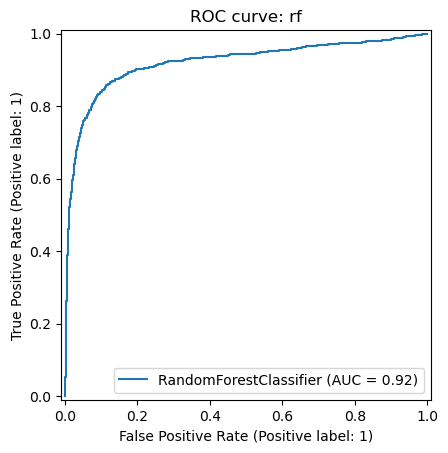

In [118]:
RocCurveDisplay.from_estimator(best_model, X_test, y_test)
plt.title("ROC curve: " + best_name)
plt.show()

- confusion matrix;

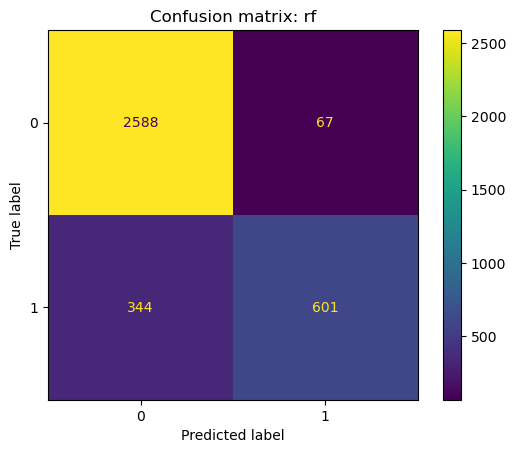

In [119]:
ConfusionMatrixDisplay.from_estimator(best_model, X_test, y_test)
plt.title("Confusion matrix: " + best_name)
plt.show()


#### 2.3.6. Интерпретация (обязательно)

Для **лучшей модели** (по согласованному критерию – например, ROC-AUC на бинарных задачах или `f1_macro` на мультиклассе):

- посчитать **permutation importance** (top-10/15 признаков);
- кратко интерпретировать: какие признаки влияют сильнее и насколько это похоже на ожидания по данным.

In [120]:
pi = permutation_importance(
    best_model,
    X_test, y_test,
    n_repeats=10,              
    random_state=RANDOM_STATE,
    scoring="roc_auc",
    n_jobs=-1
)

imp = pd.DataFrame({
    "feature": X_test.columns,
    "importance_mean": pi.importances_mean,
    "importance_std": pi.importances_std
}).sort_values("importance_mean", ascending=False)

imp.head(15)


,feature,importance_mean,importance_std
15,f16,0.054317,0.004312
0,f01,0.015988,0.001975
18,f19,0.013890,0.002057
11,f12,0.010800,0.001097
22,f23,0.010711,0.001651
6,f07,0.009608,0.001515
29,f30,0.008776,0.001172
7,f08,0.008730,0.001179
17,f18,0.008540,0.000357
1,f02,0.008465,0.001510


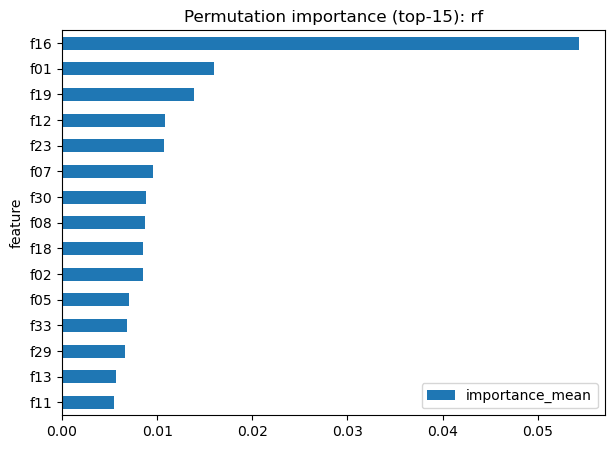

In [121]:
imp.head(15).plot(kind="barh", x="feature", y="importance_mean", figsize=(7, 5))
plt.gca().invert_yaxis()
plt.title("Permutation importance (top-15): " + best_name)
plt.show()

### 2.4. Артефакты эксперимента (обязательно)

В папке `homeworks/HW06/artifacts/` должны быть:

- `metrics_test.json` (или `.csv`) – финальные метрики на test по всем моделям;
- `search_summaries.json` – лучшие параметры и CV-score для тех моделей, где был подбор;
- `best_model.joblib` – сохранённая лучшая модель;
- `best_model_meta.json` – метаданные: какая модель лучшая, какими параметрами, какие метрики на test;
- `figures/` – минимум 2 изображения (например, ROC/PR + confusion matrix или importance).

In [122]:
with open("artifacts/metrics_test.json", "w", encoding="utf-8") as f:
    json.dump(metrics_test, f, ensure_ascii=False, indent=2)

search_summaries = {
    "tree": {"best_params": search_tree.best_params_, "best_cv_score": float(search_tree.best_score_)},
    "rf": {"best_params": search_rf.best_params_, "best_cv_score": float(search_rf.best_score_)},
    "gb": {"best_params": search_gb.best_params_, "best_cv_score": float(search_gb.best_score_)},
}
with open("artifacts/search_summaries.json", "w", encoding="utf-8") as f:
    json.dump(search_summaries, f, ensure_ascii=False, indent=2)

joblib.dump(best_model, "artifacts/best_model.joblib")

best_model_meta = {
    "best_model_name": best_name,
    "selection_metric": "roc_auc",
    "best_model_params": best_model.get_params(),
    "test_metrics": metrics_test[best_name],
}
with open("artifacts/best_model_meta.json", "w", encoding="utf-8") as f:
    json.dump(best_model_meta, f, ensure_ascii=False, indent=2)

ConfusionMatrixDisplay.from_estimator(best_model, X_test, y_test)
plt.title("Confusion matrix: " + best_name)
plt.tight_layout()
plt.savefig("artifacts/figures/confusion_matrix.png", dpi=150)
plt.close()

RocCurveDisplay.from_estimator(best_model, X_test, y_test)
plt.title("ROC curve: " + best_name)
plt.tight_layout()
plt.savefig("artifacts/figures/roc_curve.png", dpi=150)
plt.close()
